In [2]:
import torch 
torch.set_default_dtype(torch.float64)
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.kernels import *
from src.GPPW import GPPW
from src.utils.smooth_hot import smooth_hot
from data.lissajous import *
from src.utils.plots import *

plt.style.use('ggplot')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.style.use('default')
plt.rcParams.update({
	"text.usetex": True,
	"font.family": "serif",
	"figure.figsize": [12, 5]
})

def min_eigv(x):
	return torch.linalg.eigvalsh(x)[0].real.min()

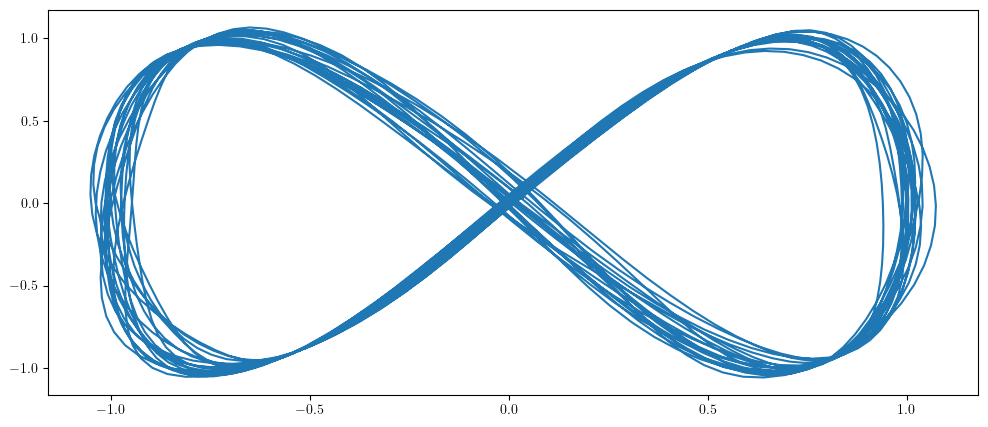

In [3]:
periodic = False
full_n = 100
full_r = 20

x_full, y_full, cycle_idcs, m, S = get_data(periodic, full_n, full_r)
plt.plot(*y_full.T)

In [4]:
train_reps = full_r
n_train = 20
x_train, y_train = to_train(x_full, y_full, full_n, train_reps, n_train) 
print(y_train.shape, x_train.shape)

model = GPPW(
	x_train, y_train, 
	[NSPeriodicKernel(1.0), NSPeriodicKernel(1.0)], PeriodicWeightKernel(1.0),
	learn_out_var=True,
	num_latents= 10
)
model.train()
iterations = 100
losses1 = model.fit(lr=0.1, iterations=iterations, batch_size=5)
iterations = 200
losses2 = model.fit_weight(lr=0.1, iterations=iterations)

torch.Size([20, 20, 2]) torch.Size([20, 20, 1])


it: 199 - loss: -2.117e+03: 100%|██████████| 200/200 [00:10<00:00, 19.10it/s]


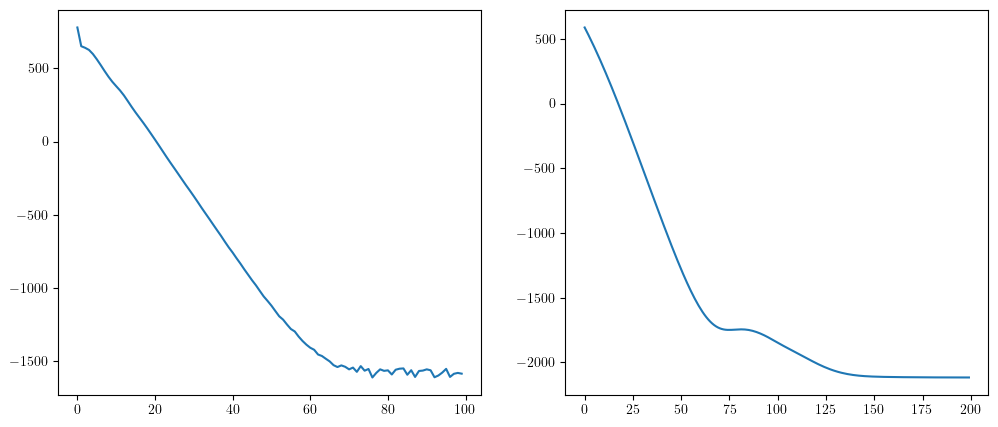

In [5]:
plt.subplot(121)
plt.plot(losses1)
plt.subplot(122)
plt.plot(losses2)

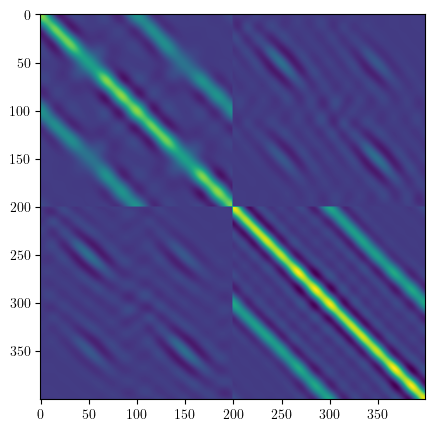

<Figure size 1200x500 with 0 Axes>

In [6]:
with torch.no_grad():
	mu, cov = model.generate(x_full[:200] + 100, with_noise=False)
	plt.imshow(cov)
	plt.figure()

<Figure size 1200x500 with 0 Axes>

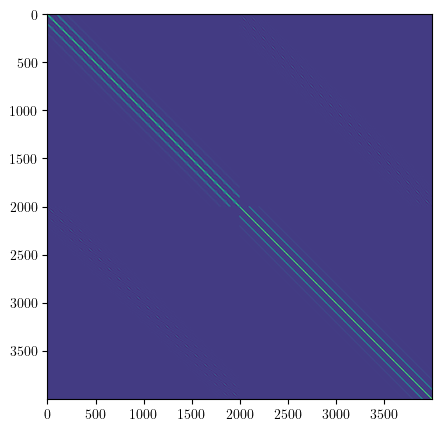

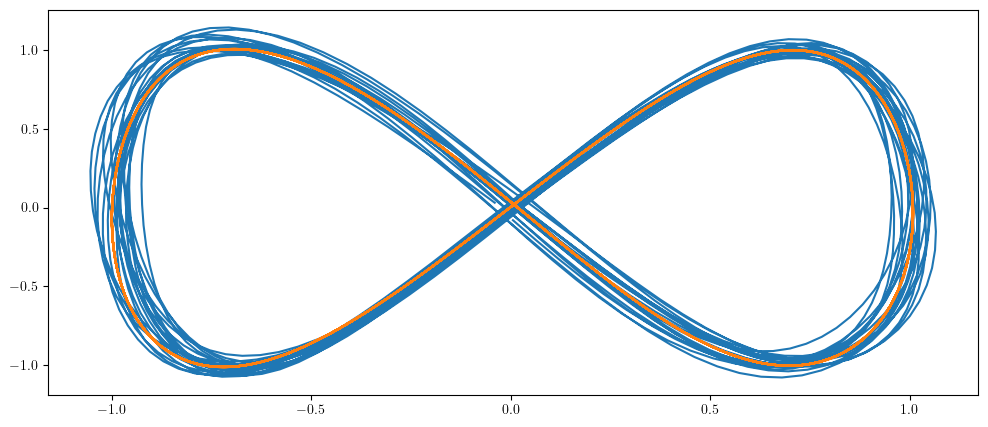

<Figure size 1200x500 with 0 Axes>

In [7]:
x_test = x_full + 100
with torch.no_grad():
	mu, cov = model.generate(x_test, with_noise=False)
	plt.imshow(cov)
	plt.figure()

s = mu + model.cholesky(cov) @ torch.randn_like(mu)
s = s.reshape(2, -1)
m = mu.reshape(2, -1)

plt.plot(*s)
plt.plot(*m)
plt.figure()

In [8]:
from matplotlib.collections import LineCollection
import numpy as np

# https://matplotlib.org/stable/gallery/lines_bars_and_markers/multicolored_line.html
def colored_line(x, y, c, ax, **lc_kwargs):
	# Default the capstyle to butt so that the line segments smoothly line up
	default_kwargs = {"capstyle": "butt"}
	default_kwargs.update(lc_kwargs)

	# Compute the midpoints of the line segments. Include the first and last points
	# twice so we don't need any special syntax later to handle them.
	x = np.asarray(x)
	y = np.asarray(y)
	x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
	y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

	# Determine the start, middle, and end coordinate pair of each line segment.
	# Use the reshape to add an extra dimension so each pair of points is in its
	# own list. Then concatenate them to create:
	# [
	#   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
	#   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
	#   ...
	# ]
	coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
	coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
	coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
	segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

	lc = LineCollection(segments, **default_kwargs)
	lc.set_array(c)  # set the colors of each segment

	return ax.add_collection(lc)

<>:70: SyntaxWarning: invalid escape sequence '\%'
<>:70: SyntaxWarning: invalid escape sequence '\%'
C:\Users\elias\AppData\Local\Temp\ipykernel_41928\2619746234.py:70: SyntaxWarning: invalid escape sequence '\%'
  edgecolor='none', label=f'{int(100*confidence)}\% confidence')
C:\Users\elias\AppData\Local\Temp\ipykernel_41928\2619746234.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(cbar.get_ticks(), fontsize=15)
C:\Users\elias\AppData\Local\Temp\ipykernel_41928\2619746234.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=15)
C:\Users\elias\AppData\Local\Temp\ipykernel_41928\2619746234.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_tic

Text(0.5, 1.0, '$\\gamma$')

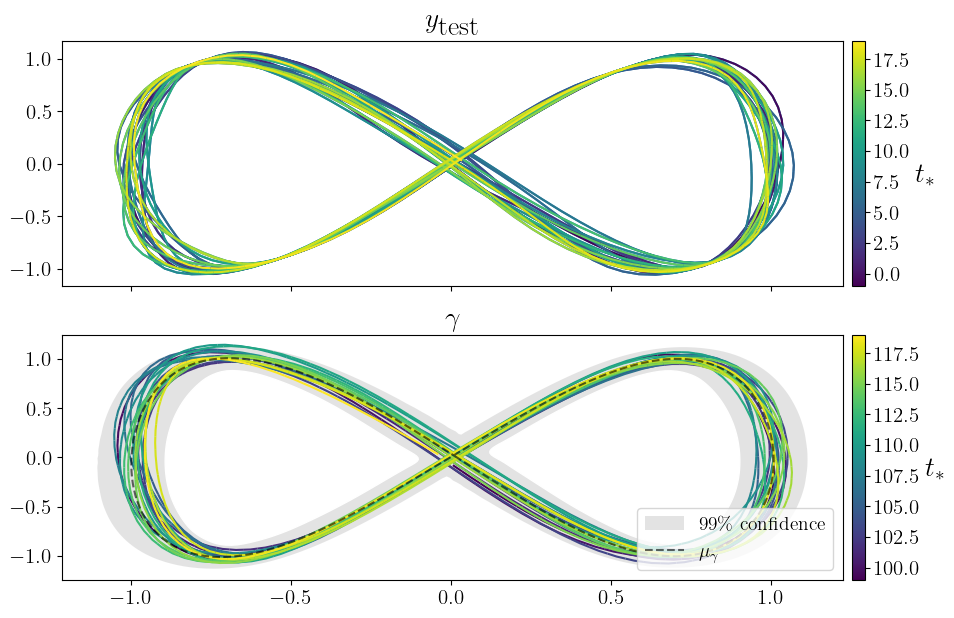

In [9]:
from scipy.stats import chi2
from shapely.geometry import Point
from shapely.affinity import scale, rotate, translate
from shapely.ops import unary_union
from scipy.interpolate import splprep, splev

plt.style.use('default')
plt.rcParams.update({
	"text.usetex": True,
	"font.family": "serif",
	# Use LaTeX default serif font.
	# "font.serif": [],
	"figure.figsize": [12, 4]
})

# L = torch.cholesky(cov + 1e-6 * torch.eye(len(cov)))
with torch.no_grad():
	mu_, cov_ = model.generate(torch.linspace(0, 1, 200))


mu_ = mu_.reshape(2, -1).detach().numpy()
cov_np = cov_.detach().numpy()
x_mean = mu_[0]
y_mean = mu_[1]
N = mu_.shape[-1]

confidence = 0.99
q = chi2.ppf(confidence, df=2)

ellipses = []

for i in range(0, N, 1):
	S = np.array([
		[cov_np[i, i], cov_np[i, N + i]],
		[cov_np[N + i, i], cov_np[N + i, N + i]]
	])
	vals, vecs = np.linalg.eigh(S)
	vals = vals.clip(0)
	a, b =  np.sqrt(q * vals)
	angle = np.degrees(np.arctan2(vecs[1,1], vecs[0,1]))

	circle = Point(0, 0).buffer(1.0, resolution=10) 
	ell = scale(circle, b, a)            
	ell = rotate(ell, angle, origin=(0, 0))            
	ell = translate(ell, x_mean[i], y_mean[i])
	ellipses.append(ell)


# train data
fig, axes = plt.subplots(2, 1, figsize=[12, 7], sharex=True)

axes[0].plot(*y_full.T)
lines = colored_line(y_full.T[0].squeeze(), y_full.T[1].squeeze(), x_full.squeeze() - 1, axes[0],
		linewidth=1.5,
		# label=r'$\gamma$'
		)
cbar = fig.colorbar(lines, pad=0.01)
cbar.set_ticklabels(cbar.get_ticks(), fontsize=15)
cbar.set_label('$t_*$', rotation=360, fontsize=20, labelpad=10.0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=15)

# test data
region = unary_union(ellipses)
exterior = region.exterior.xy

smooth = 0.001
tck, u = splprep(exterior, s=smooth, per=True)
exterior = splev(np.linspace(0,1,2*N), tck)
axes[1].fill(*exterior, alpha=0.2, color=colors[3], 
	edgecolor='none', label=f'{int(100*confidence)}\% confidence')

for inter in region.interiors:
	inter = inter.xy
	tck, u = splprep(inter, s=smooth, per=True)
	inter = splev(np.linspace(0,1,N), tck)
	axes[1].fill(*inter, color='white')

axes[1].plot(x_mean, y_mean, color='k', linestyle='--', zorder=3,
	lw=1.5, alpha=0.6, label=r'$\mu_\gamma$')

lines = colored_line(s[0].squeeze(), s[1].squeeze(), x_test.squeeze() - 1, axes[1],
		linewidth=1.5,
		)
cbar = fig.colorbar(lines, pad=0.01)
cbar.set_ticklabels(cbar.get_ticks(), fontsize=15)
cbar.set_label('$t_*$', rotation=360, fontsize=20, labelpad=10.0)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=15)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=15)

axes[1].legend(fontsize=14, loc='lower right')


axes[0].set_title(r'$y_\textrm{test}$', fontsize=20, pad=10.0)
axes[1].set_title(r'$\gamma$', fontsize=20)